# Simulación Orbital  
## Acercamiento Tierra-Apophis con modelo de N-cuerpos

### Resumen
En este trabajo se modela la dinámica orbital de un sistema planetario simplificado usando integración numérica de N-cuerpos en unidades canónicas.  
Se analiza en particular el comportamiento de Apophis respecto a la Tierra, incluyendo trayectoria, distancia mínima, conservación de energía y magnitudes globales del sistema.

### Objetivo general
Estudiar la evolución orbital de Apophis entre 2026 y 2046, y estimar su distancia mínima a la Tierra mediante simulación numérica.

### Objetivos específicos
- Construir el sistema dinámico con Sol, Tierra, Luna, Marte, Apophis y Júpiter.
- Integrar ecuaciones de movimiento con métodos numéricos.
- Comparar resultados entre el esquema implementado y REBOUND (IAS15).
- Obtener y visualizar:
  - Órbitas en el plano XY.
  - Distancia Tierra-Apophis en función del tiempo.
  - Magnitudes globales (momentum lineal, momentum angular y virial, según corresponda).

### Marco físico y numérico
- Modelo gravitacional newtoniano de N-cuerpos.
- Escalas canónicas:
  - Longitud: 1 UA.
  - Masa: masa solar.
  - Tiempo: $U_T=\sqrt{U_L^3/(G\,U_M)}$.




In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from plotly import graph_objects as go
import rebound as rb
from astropy.time import Time
import plotly.express as px


In [70]:
# Se hara un sistema con el Sol, la tierra, Apophis, Jupiter. y se hara una simulacion de 20 aÃƒÂ±os para ver la trayectoria de Apophis. Se hara una simulacion con el metodo de Euler y otra con el metodo de Runge-Kutta de orden 4 para comparar los resultados. Se hara una grafica de la trayectoria de Apophis en el plano xy y otra grafica de la distancia entre Apophis y la Tierra en funcion del tiempo.
fecha_inicio = '2026-3-22'
fecha_final = '2046-3-22'
tabla_sol,jd_sol, X_sol = pc.consulta_horizons('10',location='@SSB',epochs= fecha_inicio)
tabla_tierra,jd_tierra, X_tierra = pc.consulta_horizons('399',location='@SSB',epochs= fecha_inicio)
tabla_apophis,jd_apophis, X_apophis = pc.consulta_horizons('99942',location='@SSB',epochs= fecha_inicio)
tabla_jupiter,jd_jupiter, X_jupiter = pc.consulta_horizons('599',location='@SSB',epochs= fecha_inicio)
tabla_marte,jd_marte, X_marte = pc.consulta_horizons('499',location='@SSB',epochs= fecha_inicio)
tabla_luna,jd_luna, X_luna = pc.consulta_horizons('301',location='@SSB',epochs= fecha_inicio)
    
# Se extraen las posiciones y velocidades de cada cuerpo
pos_sol = X_sol[0:3]
vel_sol = X_sol[3:6]
pos_tierra = X_tierra[0:3]
vel_tierra = X_tierra[3:6]
pos_apophis = X_apophis[0:3]
vel_apophis = X_apophis[3:6]
pos_jupiter = X_jupiter[0:3]
vel_jupiter = X_jupiter[3:6]
pos_marte = X_marte[0:3]
vel_marte = X_marte[3:6]
pos_luna = X_luna[0:3]
vel_luna = X_luna[3:6]


print('Posicion del Sol:', pos_sol)
print('Velocidad del Sol:', vel_sol)    
print('Posicion de la Tierra:', pos_tierra)
print('Velocidad de la Tierra:', vel_tierra)
print('Posicion de Apophis:', pos_apophis)
print('Velocidad de Apophis:', vel_apophis)
print('Posicion de Jupiter:', pos_jupiter)
print('Velocidad de Jupiter:', vel_jupiter)
print('Posicion de la Luna:', pos_luna)
print('Velocidad de la Luna:', vel_luna)




Posicion del Sol: [-3.74082124e+08 -8.21077523e+08  1.80394185e+07]
Velocidad del Sol: [12.07660487  1.66469579 -0.24321337]
Posicion de la Tierra: [-1.49395136e+11 -3.45562165e+09  1.86670252e+07]
Velocidad de la Tierra: [ 6.26795448e+01 -2.99038132e+04  9.94953730e-01]
Posicion de Apophis: [ 2.52980785e+10  1.38445391e+11 -6.80774098e+09]
Velocidad de Apophis: [-28082.51741589  10931.64170382  -1248.02944168]
Posicion de Jupiter: [-3.38451934e+11  7.06530130e+11  4.64368237e+09]
Velocidad de Jupiter: [-11937.26386791  -5027.94005781    288.0081068 ]
Posicion de la Luna: [-1.49115401e+11 -3.21992269e+09  4.81325581e+07]
Velocidad de la Luna: [  -634.45906348 -29091.31027733     46.73811565]


In [71]:
#definicion de constantes
G = 6.67430e-11 # Constante de gravitaciÃƒÂ³n universal en m^3 kg^-1 s^-2
M_sol = 1.989e30 # Masa del Sol en kg
M_tierra = 5.972e24 # Masa de la Tierra en kg
M_apophis = 2.7e10 # Masa de Apophis en kg
M_jupiter = 1.898e27 # Masa de Jupiter en kg
M_luna = 7.342e22 # Masa de la Luna en kg
M_marte = 6.417e23 # Masa de Marte en kg

In [72]:
# Definicion unidades canonicas
U_L = 1.496e11 # Unidad de longitud en metros (1 UA)
U_M = M_sol # Unidad de masa en kg (masa del Sol)
U_T = np.sqrt(U_L**3 / (G * U_M)) # Unidad de tiempo en segundos

In [73]:
pos_sol = pos_sol / U_L
pos_tierra = pos_tierra / U_L
pos_apophis = pos_apophis / U_L
pos_marte = pos_marte / U_L
pos_jupiter = pos_jupiter / U_L
pos_luna = pos_luna / U_L
vel_sol = vel_sol / (U_L / U_T)
vel_tierra = vel_tierra / (U_L / U_T)
vel_apophis = vel_apophis / (U_L / U_T)
vel_marte = vel_marte / (U_L / U_T)
vel_jupiter = vel_jupiter / (U_L / U_T)
vel_luna = vel_luna / (U_L / U_T)

In [74]:
M_sol = M_sol / U_M      # → 1
M_tierra = M_tierra / U_M
M_apophis = M_apophis / U_M
M_jupiter = M_jupiter / U_M
M_marte = M_marte / U_M
M_luna = M_luna / U_M

In [75]:
# creare el sistema
sistema = [
    dict(m=M_sol, r=pos_sol, v=vel_sol),
    dict(m=M_tierra, r=pos_tierra, v=vel_tierra),
    dict(m= M_luna, r=pos_luna, v=vel_luna),
    dict(m=M_apophis, r=pos_apophis, v=vel_apophis),
    dict(m=M_marte, r=pos_marte, v=vel_marte),
    dict(m=M_jupiter, r=pos_jupiter, v=vel_jupiter),
    
]

# crear el tiempo de simulacion con base en las fechas de inicio y final

tiempo_inicio = Time(fecha_inicio).jd
tiempo_final = Time(fecha_final).jd

tiempo_simulacion_dias = tiempo_final - tiempo_inicio
tiempo_simulacion_anios = tiempo_simulacion_dias / 365.25

# crear el numero de pasos usando dt = 1 dia
dt = 1.0 / 365.25   # años
num_pasos = int(tiempo_simulacion_anios / dt) + 1

# vector de tiempo en JD, en dias relativos y en anios calendario
t_jd = np.linspace(tiempo_inicio, tiempo_final, num_pasos)
t_dias = t_jd - tiempo_inicio
t_anios = t_dias / 365.25
anio_inicio = Time(fecha_inicio).decimalyear
anios_calendario = anio_inicio + t_anios

#print(f"Tiempo simulacion: {tiempo_simulacion:.2f} dias")
#print(f"Tiempo simulacion: {t_anios[-1]:.2f} anios")
#print(f"Pasos: {num_pasos}")
#print(f"dt efectivo en linspace: {t_jd[1] - t_jd[0]:.6f} dias")
tiempo_simulacion_anios

c:\Users\nando\Repositorio-git-Mcenica-celeste\mec-nica-celeste\mec-nica-celeste\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


np.float64(20.0)

In [76]:

# tiempo en días
t_dias = np.linspace(0, tiempo_simulacion_dias, num_pasos)

# convertir a segundos
t_seg = t_dias * 86400

# convertir a unidades canónicas
ts = t_seg / U_T

In [77]:
print(ts[-1])

125.67729534716791


In [78]:
# Integracion con tiempo relativo construido desde el linspace en JD
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)


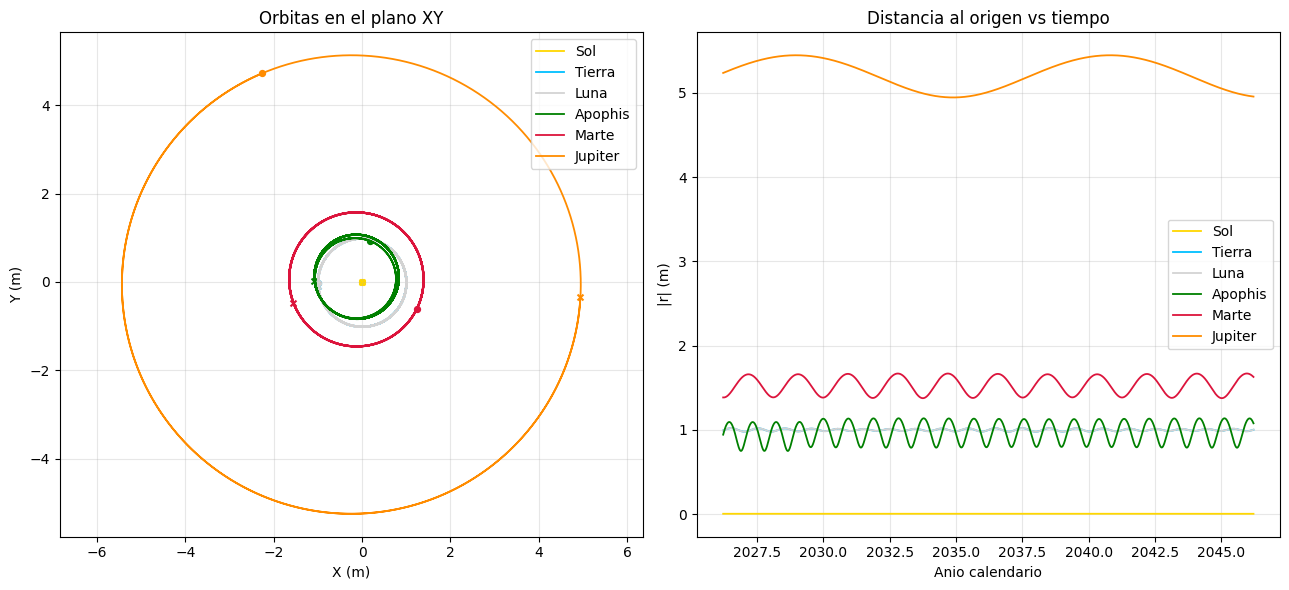

In [87]:
# Orbitas con Matplotlib (plano XY) y evolucion radial en funcion del tiempo
nombres = ['Sol', 'Tierra', 'Luna', 'Apophis', 'Marte', 'Jupiter']
colores = ['gold', 'deepskyblue', 'lightgray', 'green', 'crimson', 'darkorange']
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

# Panel 1: orbitas XY
for i, nombre in enumerate(nombres):
    ax[0].plot(rps[i, :, 0], rps[i, :, 1], lw=1.3, color=colores[i], label=nombre)
    ax[0].scatter(rps[i, 0, 0], rps[i, 0, 1], color=colores[i], s=18, marker='o')  # inicio
    ax[0].scatter(rps[i, -1, 0], rps[i, -1, 1], color=colores[i], s=18, marker='x')  # final

ax[0].set_title('Orbitas en el plano XY')
ax[0].set_xlabel('X (m)')
ax[0].set_ylabel('Y (m)')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Panel 2: distancia al origen en funcion del tiempo
for i, nombre in enumerate(nombres):
    r_mod = np.linalg.norm(rps[i, :, :], axis=1)
    ax[1].plot(anios_calendario, r_mod, lw=1.3, color=colores[i], label=nombre)

ax[1].set_title('Distancia al origen vs tiempo')
ax[1].set_xlabel('Anio calendario')
ax[1].set_ylabel('|r| (m)')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [80]:
fig = pc.plot_ncuerpos_3d(rps, vps, tipo='plotly')

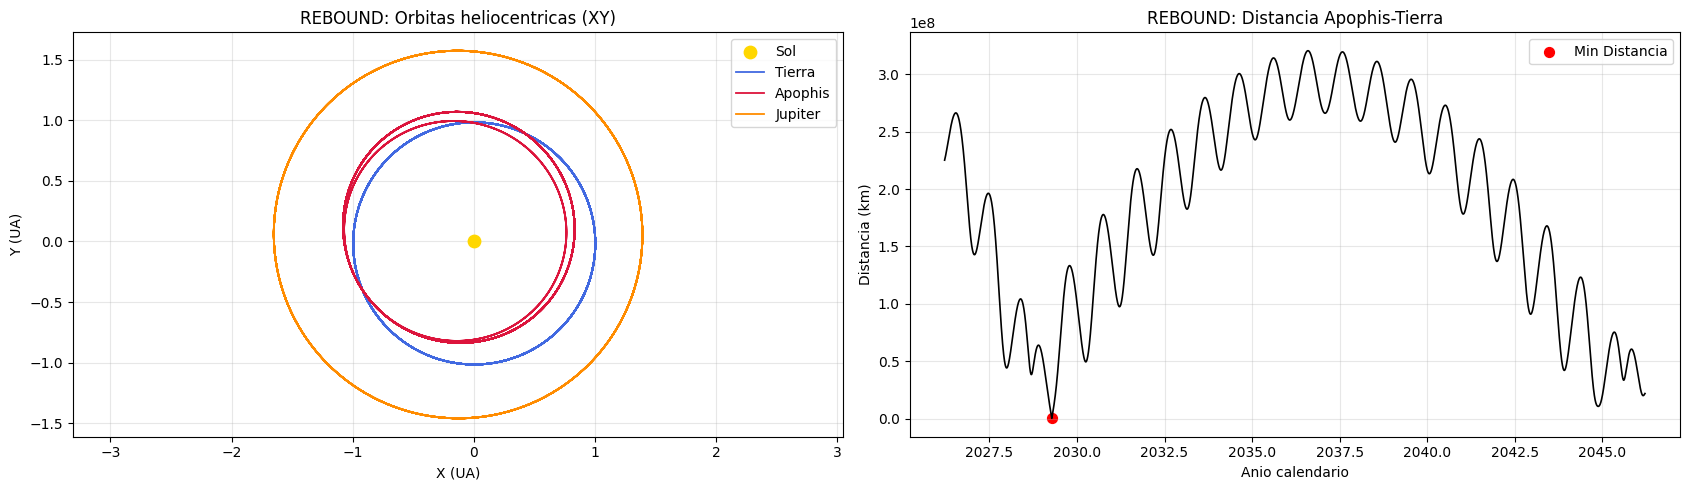

Minima distancia Apophis-Tierra: 187860.60 km en el año 2029.28


In [81]:

sim = rb.Simulation()
sim.G = 1.0
sim.integrator = 'ias15'

# Orden real en sistema:
# 0 Sol, 1 Tierra, 2 Luna, 3 Apophis, 4 Jupiter
for body in sistema:
    r = body['r']
    v = body['v']
    sim.add(m=body['m'], x=r[0], y=r[1], z=r[2], vx=v[0], vy=v[1], vz=v[2])

paso_muestreo = 1
t_dias_rb = t_dias[::paso_muestreo]
t_anios_rb = t_dias_rb / 365.25
anios_rb = anio_inicio + t_anios_rb
t_seg_rb = t_dias_rb * 86400.0
t_can_rb = t_seg_rb / U_T

rs_rb = np.zeros((len(sistema), len(t_can_rb), 3))
E_rb = np.zeros(len(t_can_rb))

for k, t in enumerate(t_can_rb):
    sim.integrate(float(t))
    E_rb[k] = sim.energy()
    for i, p in enumerate(sim.particles):
        rs_rb[i, k, 0] = p.x
        rs_rb[i, k, 1] = p.y
        rs_rb[i, k, 2] = p.z

rs_rb_helio = rs_rb - rs_rb[0:1, :, :]

fig, ax = plt.subplots(1, 2, figsize=(17, 5))

ax[0].scatter(0.0, 0.0, color='gold', s=80, label='Sol', zorder=5)
for idx, nombre, color in zip([1, 3, 4], ['Tierra', 'Apophis', 'Jupiter'], ['royalblue', 'crimson', 'darkorange']):
    ax[0].plot(rs_rb_helio[idx, :, 0], rs_rb_helio[idx, :, 1], color=color, lw=1.3, label=nombre)
ax[0].set_title('REBOUND: Orbitas heliocentricas (XY)')
ax[0].set_xlabel('X (UA)')
ax[0].set_ylabel('Y (UA)')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

dist_rb_ua = np.linalg.norm(rs_rb_helio[3] - rs_rb_helio[1], axis=1)  # Apophis - Tierra
dist_rb_km = dist_rb_ua * U_L / 1e3
ax[1].plot(anios_rb, dist_rb_km, color='black', lw=1.2)
ax[1].set_title('REBOUND: Distancia Apophis-Tierra')
ax[1].set_xlabel('Anio calendario')
ax[1].set_ylabel('Distancia (km)')
ax[1].grid(True, alpha=0.3)
#minima distancia entre Apophis y la Tierra grafica con un punto rojo
min_dist_idx = np.argmin(dist_rb_km)
ax[1].scatter(anios_rb[min_dist_idx], dist_rb_km[min_dist_idx], color='red', s=50, label='Min Distancia')
ax[1].legend()


plt.tight_layout()
plt.show()
print(f"Minima distancia Apophis-Tierra: {dist_rb_km[min_dist_idx]:.2f} km en el año {anios_rb[min_dist_idx]:.2f}")

Fecha de maximo acercamiento (modelo): 2029-04-13 00:00:00
Distancia minima Apophis-Tierra: 187,861 km
Diferencia respecto a 2029-04-13: 0.00 dias


c:\Users\nando\Repositorio-git-Mcenica-celeste\mec-nica-celeste\mec-nica-celeste\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\nando\Repositorio-git-Mcenica-celeste\mec-nica-celeste\mec-nica-celeste\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


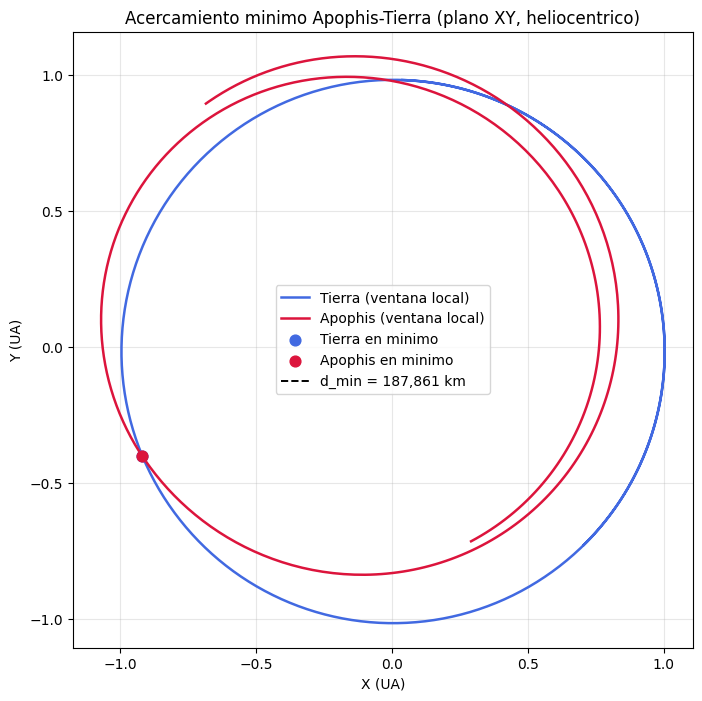

In [82]:
# Celda: acercamiento minimo 2D - indice de Apophis corregido
import numpy as np
import matplotlib.pyplot as plt


required = ['rs_rb_helio', 't_dias_rb', 'fecha_inicio', 'U_L']
for var in required:
    if var not in globals():
        raise RuntimeError(f"Falta '{var}'. Ejecuta primero la celda de REBOUND.")

r_tierra = rs_rb_helio[1]
r_apophis = rs_rb_helio[3]  

dr = r_apophis - r_tierra
dist_km = np.linalg.norm(dr, axis=1) * U_L / 1e3
i_min = int(np.argmin(dist_km))
d_min_km = dist_km[i_min]

fecha_min = (Time(fecha_inicio) + t_dias_rb[i_min]).to_datetime()
fecha_ref = Time('2029-04-13').to_datetime()
delta_dias = abs((fecha_min - fecha_ref).total_seconds()) / 86400.0

print(f"Fecha de maximo acercamiento (modelo): {fecha_min:%Y-%m-%d %H:%M:%S}")
print(f"Distancia minima Apophis-Tierra: {d_min_km:,.0f} km")
print(f"Diferencia respecto a 2029-04-13: {delta_dias:.2f} dias")

ancho = 250
i0 = max(0, i_min - ancho)
i1 = min(len(t_dias_rb), i_min + ancho + 1)

r_tierra_ua = r_tierra
r_apophis_ua = r_apophis

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(r_tierra_ua[i0:i1, 0], r_tierra_ua[i0:i1, 1], color='royalblue', lw=1.8, label='Tierra (ventana local)')
ax.plot(r_apophis_ua[i0:i1, 0], r_apophis_ua[i0:i1, 1], color='crimson', lw=1.8, label='Apophis (ventana local)')
ax.scatter(r_tierra_ua[i_min, 0], r_tierra_ua[i_min, 1], color='royalblue', s=60, marker='o', zorder=5, label='Tierra en minimo')
ax.scatter(r_apophis_ua[i_min, 0], r_apophis_ua[i_min, 1], color='crimson', s=60, marker='o', zorder=5, label='Apophis en minimo')
ax.plot([r_tierra_ua[i_min, 0], r_apophis_ua[i_min, 0]],
        [r_tierra_ua[i_min, 1], r_apophis_ua[i_min, 1]],
        color='black', ls='--', lw=1.4, label=f'd_min = {d_min_km:,.0f} km')
ax.set_title('Acercamiento minimo Apophis-Tierra (plano XY, heliocentrico)')
ax.set_xlabel('X (UA)')
ax.set_ylabel('Y (UA)')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.show()

### Comparación entre el modelo e intentando refinar con ayuda de copilot el modelo para ver si se logra precisión

DISTANCIA MINIMA TIERRA-APOPHIS (Simulacion REBOUND)
Fecha del acercamiento: 2029-04-13
Distancia minima:    187,860.6 km
Distancia minima:     0.001256 UA
Fecha referencia (2029-04-13): 2029-04-13
Diferencia:   +0 dias


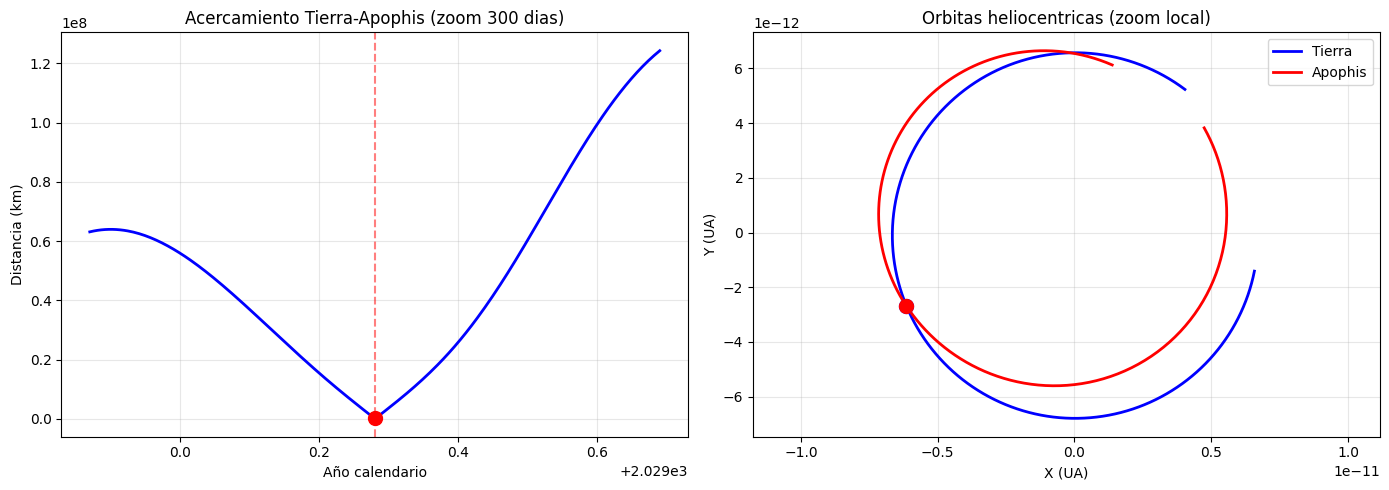

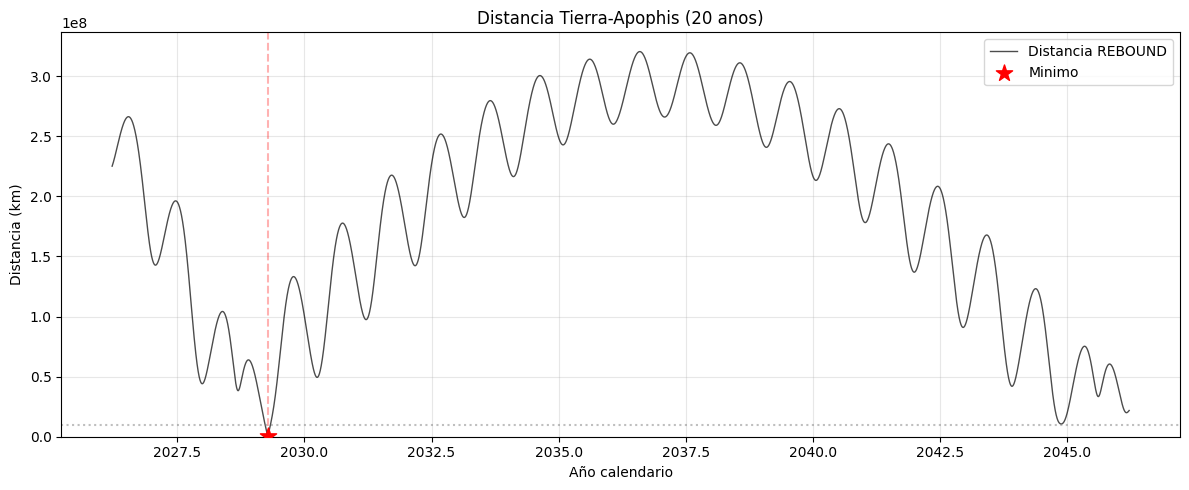

In [83]:
# =====================================================
# CALCULO: Distancia minima Tierra-Apophis (REBOUND)
# =====================================================

# Indices en rs_rb_helio
i_tierra = 1
i_apophis = 3

# Distancia Tierra-Apophis en cada momento
r_tierra_rb = rs_rb_helio[i_tierra]
r_apophis_rb = rs_rb_helio[i_apophis]

delta_r = r_apophis_rb - r_tierra_rb
dist_ta_ua = np.linalg.norm(delta_r, axis=1)  # en UA canonicas
dist_ta_km = dist_ta_ua * U_L / 1e3  # convertir a km

# Encontrar minimo
idx_min = np.argmin(dist_ta_km)
d_min_km = dist_ta_km[idx_min]
d_min_ua = dist_ta_ua[idx_min]

# Fecha del minimo
t_dias_min = t_dias_rb[idx_min]
fecha_min = Time(fecha_inicio).to_datetime() + np.timedelta64(int(t_dias_min), 'D')

# Comparacion con evento conocido
fecha_referencia = Time('2029-04-13').to_datetime()
delta_dias_ref = (fecha_min - fecha_referencia).days

print('='*60)
print('DISTANCIA MINIMA TIERRA-APOPHIS (Simulacion REBOUND)')
print('='*60)
print(f'Fecha del acercamiento: {fecha_min:%Y-%m-%d}')
print(f'Distancia minima: {d_min_km:>12,.1f} km')
print(f'Distancia minima: {d_min_ua:>12.6f} UA')
print(f'Fecha referencia (2029-04-13): {fecha_referencia:%Y-%m-%d}')
print(f'Diferencia: {delta_dias_ref:>+4d} dias')
print('='*60)

# Grafico: Acercamiento minimo (zoom local)
ancho = 150
i_start = max(0, idx_min - ancho)
i_end = min(len(t_dias_rb), idx_min + ancho + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Distancia vs tiempo (zoom en evento)
ax1.plot(anios_rb[i_start:i_end], dist_ta_km[i_start:i_end], 'b-', lw=2)
ax1.scatter([anios_rb[idx_min]], [d_min_km], color='red', s=100, zorder=5)
ax1.axvline(anios_rb[idx_min], color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Año calendario')
ax1.set_ylabel('Distancia (km)')
ax1.set_title('Acercamiento Tierra-Apophis (zoom 300 dias)')
ax1.grid(True, alpha=0.3)

# Panel 2: Orbita XY heliocentrica (zoom local)
r_tierra_zoom = r_tierra_rb[i_start:i_end] / U_L
r_apophis_zoom = r_apophis_rb[i_start:i_end] / U_L

ax2.plot(r_tierra_zoom[:, 0], r_tierra_zoom[:, 1], 'b-', lw=2, label='Tierra')
ax2.plot(r_apophis_zoom[:, 0], r_apophis_zoom[:, 1], 'r-', lw=2, label='Apophis')
ax2.scatter([r_tierra_zoom[idx_min - i_start, 0]], [r_tierra_zoom[idx_min - i_start, 1]], 
            color='blue', s=100, marker='o', zorder=5)
ax2.scatter([r_apophis_zoom[idx_min - i_start, 0]], [r_apophis_zoom[idx_min - i_start, 1]], 
            color='red', s=100, marker='o', zorder=5)
ax2.set_xlabel('X (UA)')
ax2.set_ylabel('Y (UA)')
ax2.set_title('Orbitas heliocentricas (zoom local)')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Panel 3: Distancia global
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(anios_rb, dist_ta_km, 'k-', lw=1, alpha=0.7)
ax.scatter([anios_rb[idx_min]], [d_min_km], color='red', s=150, zorder=5, marker='*')
ax.axhline(10e6, color='gray', linestyle=':', alpha=0.5)
ax.axvline(anios_rb[idx_min], color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Año calendario')
ax.set_ylabel('Distancia (km)')
ax.set_title('Distancia Tierra-Apophis (20 anos)')
ax.grid(True, alpha=0.3)
ax.legend(['Distancia REBOUND', 'Minimo'], loc='upper right')
ax.set_ylim([0, max(dist_ta_km) * 1.05])
plt.tight_layout()
plt.show()

In [84]:
constantes["RCM"][0]

array([-0.0046576 , -0.0009811 ,  0.00015005])

In [85]:
constantes

{'M': np.float64(1.0009576104172948),
 'RCM': array([[-0.0046576 , -0.0009811 ,  0.00015005],
        [-0.0046572 , -0.00098295,  0.00015007],
        [-0.0046568 , -0.00098481,  0.00015008],
        ...,
        [-0.00175239, -0.01453422,  0.00028358],
        [-0.00175199, -0.01453607,  0.0002836 ],
        [-0.0017516 , -0.01453793,  0.00028362]], shape=(7306, 3)),
 'PCM': array([ 2.31448673e-05, -1.07973459e-04,  1.06381208e-06]),
 'L': array([4.86199766e-05, 9.02318905e-06, 2.17588575e-03]),
 'K': array([9.19913013e-05, 9.19780776e-05, 9.19648547e-05, ...,
        1.02246540e-04, 1.02250054e-04, 1.02253547e-04], shape=(7306,)),
 'U': array([-0.00018537, -0.00018536, -0.00018534, ..., -0.00019563,
        -0.00019563, -0.00019563], shape=(7306,)),
 'E': np.float64(-9.337878369338829e-05)}